In [16]:
import torch

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print(f"Using: {device}")

Using: cpu


In [17]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
words = open('names.txt','r').read().splitlines()

In [19]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [20]:
block_size = 3
X,Y = [],[]

for w in words:
    context = [0]*block_size
    #print(w)
    for ch in w + '.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[ix] for ix in context),'----->',itos[ix])
        context=context[1:]+[ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [21]:
def build_dataset(words):
    block_size = 3#how many letters we take to print the next
    X,Y = [],[]

    for w in words:
        context = [0]*block_size
        #print(w)
        for ch in w + '.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[ix] for ix in context),'----->',itos[ix])
            context=context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)

    return X,Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182579, 3]) torch.Size([182579])
torch.Size([22695, 3]) torch.Size([22695])
torch.Size([22866, 3]) torch.Size([22866])


In [22]:
#Xtr = Xtr.to(device)
#Ytr = Ytr.to(device)

In [23]:
# = torch.tanh(emb.view(-1,6)@W1 + B1)  #-1 keeps the other dimensions here it would be emb.shape[0]==32

In [24]:
#counts = logits.exp()
#probs = counts/counts.sum(1,keepdim=True)
#loss = -probs[torch.arange(32),Y].log().mean() highly inefficient form of cross-entropy function as they create new tensors

In [25]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228140, 3]), torch.int64, torch.Size([228140]), torch.int64)

In [26]:
n_embd = 10 #charecter embedding dimensionality
n_hidden = 200 #hidden layer neurons

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd),generator=g)#.to(device)
# Kaiming init for W1 (gain=5/3 for tanh, fan_in = n_embd * block_size)
W1 = torch.randn(n_embd*block_size,n_hidden,generator=g)*(5/3)/((n_embd*block_size)**0.5)#.to(device)
#B1 = torch.randn(n_hidden,generator= g)*0.2#.to(device)
W2 = torch.randn((n_hidden,vocab_size),generator=g)*0.01#.to(device)
B2 = torch.randn(vocab_size,generator=g)*0#.to(device)

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))
parameters = [C,W1,W2,B2,bnbias,bngain]
E = 1e-5
for p in parameters:
    p.requires_grad=True

sum(p.nelement() for p in parameters)

12097

In [27]:
lossi,stepi =[],[]

In [28]:
batch_size = 32
steps = 200000
for i in range(steps+1):
    ix = torch.randint(0,Xtr.shape[0],(batch_size,)) #minibatch
    #forward pass
    emb = C[Xtr[ix]]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 #+B1
    bnmeani = hpreact.mean(0,keepdim=True)
    bnstdi = hpreact.std(0,keepdim=True)
    hpreact = bngain*(hpreact - bnmeani)/ (bnstdi+E) + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact)
    logits = h@W2 + B2
    loss = F.cross_entropy(logits,Ytr[ix])
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #updation
    lr = 0.1 if i<100000 else 0.01
    for p in parameters:
        p.data += -lr*p.grad
    lossi.append(loss.log10().item())
    stepi.append(i)
    if(i%10000==0):
        print(i,"/","200000"," = ",loss.item())


0 / 200000  =  3.27974009513855
10000 / 200000  =  2.1271414756774902
20000 / 200000  =  2.3914034366607666
30000 / 200000  =  2.518378734588623
40000 / 200000  =  2.714449644088745
50000 / 200000  =  2.499335765838623
60000 / 200000  =  2.2306125164031982
70000 / 200000  =  1.883968472480774
80000 / 200000  =  1.98262357711792
90000 / 200000  =  2.3054444789886475
100000 / 200000  =  2.0617170333862305
110000 / 200000  =  2.0475683212280273
120000 / 200000  =  2.2749531269073486
130000 / 200000  =  2.0807321071624756
140000 / 200000  =  1.75112783908844
150000 / 200000  =  1.5467395782470703
160000 / 200000  =  2.215486764907837
170000 / 200000  =  1.8206117153167725
180000 / 200000  =  2.0272090435028076
190000 / 200000  =  2.1438210010528564
200000 / 200000  =  1.676877498626709


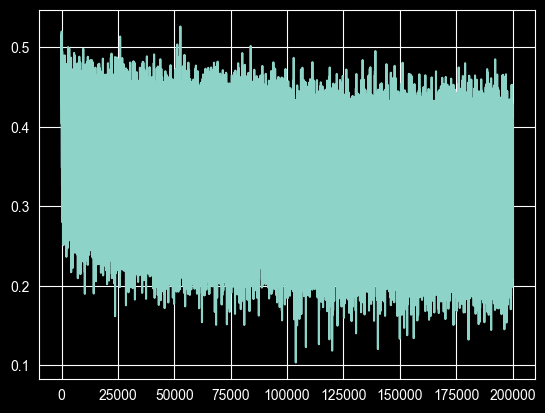

In [29]:
plt.plot(stepi,lossi)

In [30]:
'''with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact =  embcat @ W1 + B1
    bnmean = hpreact.mean(0,keepdim=True)
    bnstd = hpreact.std(0,keepdim=True)'''

'with torch.no_grad():\n    emb = C[Xtr]\n    embcat = emb.view(emb.shape[0],-1)\n    hpreact =  embcat @ W1 + B1\n    bnmean = hpreact.mean(0,keepdim=True)\n    bnstd = hpreact.std(0,keepdim=True)'

In [31]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr,Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact =  embcat @ W1 #+ B1
    hpreact = bngain*(hpreact - bnmean_running) / (bnstd_running+E) + bnbias
    h = torch.tanh(hpreact)
    logits = h@W2 +B2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 2.0712532997131348
val 2.1057240962982178


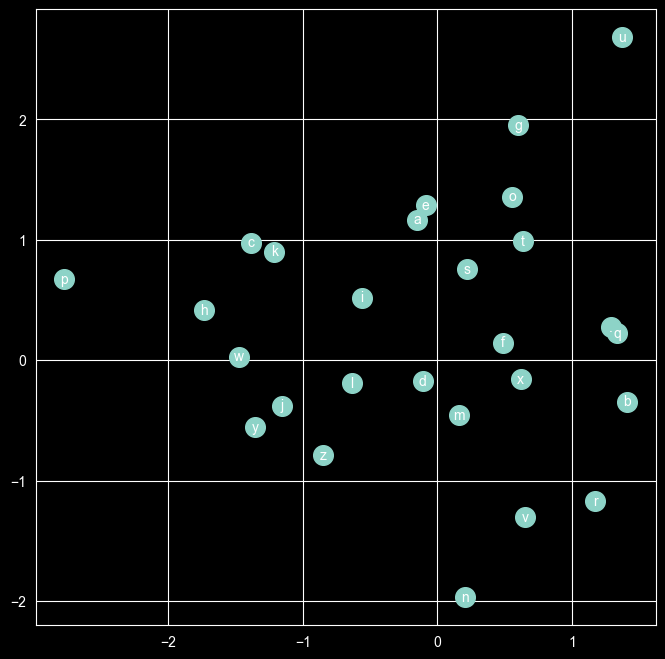

In [32]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [33]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0],-1)
      hpreact =  embcat @ W1 #+ B1
      hpreact = bngain*(hpreact - bnmean_running) / (bnstd_running+E) + bnbias
      h = torch.tanh(hpreact)
      logits = h@W2 +B2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carla.
faturlee.
frigrachelly.
skanna.
eja.
hubradgerric.
kaeli.
ner.
kia.
chaily.
kaleigh.
ham.
join.
quinton.
lilea.
jadiquinterri.
jaryxi.
jace.
pirra.
mel.


In [34]:
#2.47 with w2 =* 0.1,b2 =* 0.0
#2.17 , 2.13 for val loss with b1 =* 0.2 from *0.0 [resolving the dead neurons part]
#1.85 and 2.10 after kaiming init
#2.21 and 2.15 after bngain and bnbias stuff , it got worse
#1.95 and 2.15
#2.13 and 2.15 bit more cleaner
#2.07 and 2.10 implemented running batch norm mean and std , 1.67 in the loop